In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from scipy.stats import norm,multivariate_normal

In [2]:
df=pd.read_csv('data.csv')


In [3]:
df.shape

(500, 2)

In [4]:
df.head()

,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


In [5]:
df.describe()

,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770


In [23]:
# initialize values
m1 = np.mean(df, axis=0) + np.random.randn(df.shape[1])
m2 = np.mean(df, axis=0) - np.random.randn(df.shape[1])
m3=  np.mean(df,axis=0) + np.random.randn(df.shape[1])
s1 = np.cov(df.T)
s2 = np.cov(df.T)
s3=np.cov(df.T)
w1, w2,w3 = 0.5, 0.5 ,0.5

In [24]:
print(m1,m2,m3)

[ 58.73438173 170.0754781 ] [ 60.89912877 169.37035768] [ 60.30880737 170.09541161]


In [8]:
df=df.to_numpy()

In [25]:
for j in range(100):
    k1 = []
    k2 = []
    k3=[]
    for i in range(df.shape[0]):
        p1 = multivariate_normal.pdf(df[i], mean=m1, cov=s1)
        p2 = multivariate_normal.pdf(df[i], mean=m2, cov=s2)
        p3=multivariate_normal.pdf(df[i],mean=m3,cov=s3)
        r1 = (w1 * p1)/(w1*p1+w2*p2+w3*p3)
        r2 = (w2 * p2)/(w1*p1+w2*p2+w3*p3)
        r3=(w3*p3)/(w1*p1+w2*p2+w3*p3)

        k1.append(r1)
        k2.append(r2)
        k3.append(r3)

    k1 = np.array(k1)
    k2 = np.array(k2)
    k3=np.array(k3)

    # M-step: Update parameters
    m1 = np.sum(k1[:, None] * df, axis=0) / np.sum(k1)
    m2 = np.sum(k2[:, None] * df, axis=0) / np.sum(k2)
    m3=np.sum(k3[:,None]*df,axis=0)/np.sum(k3)
    s1 = np.dot((k1[:, None] * (df - m1)).T, (df - m1)) / np.sum(k1)
    s2 = np.dot((k2[:, None] * (df - m2)).T, (df - m2)) / np.sum(k2)
    s3=np.dot((k3[:,None]*(df-m3)).T,(df-m3))/np.sum(k3)
    w1 = np.sum(k1) / df.shape[0]
    w2 = np.sum(k2) / df.shape[0]
    w3=np.sum(k3)/df.shape[0]



In [26]:
n_clusters=3
means=np.array([m1,m2,m3])
covariances=np.array([s1,s2,s3])
weights=np.array([w1,w2,w3])
responsibilities=np.zeros((df.shape[0],n_clusters))

In [27]:
for k in range(n_clusters):
    responsibilities[:, k] = multivariate_normal.pdf(df, mean=means[k], cov=covariances[k]) * weights[k]
    cluster_assignments = np.argmax(responsibilities, axis=1)

<ipython-input-35-3ba1d4a0c134>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


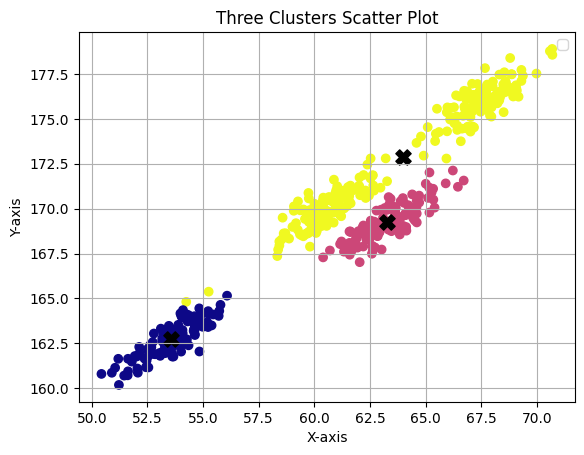

In [35]:
import matplotlib.pyplot as plt
plt.scatter(df[:,0], df[:,1] ,c=cluster_assignments,cmap='plasma')
plt.scatter(m1[0], m1[1], color='black',marker='X',s=120)
plt.scatter(m2[0], m2[1], color='black',marker='X',s=120)
plt.scatter(m3[0], m3[1], color='black',marker='X',s=120)
plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Three Clusters Scatter Plot")
plt.grid(True)

plt.show()
